In [19]:
from openpiv import tools, pyprocess, validation, filters, scaling, piv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
img_path = '/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_100.0_E_1000.0_nu_0.3/im_00_cell_003_img.npy'

images = np.load(img_path)

In [4]:
frame_a = images[0]
frame_b = images[1]

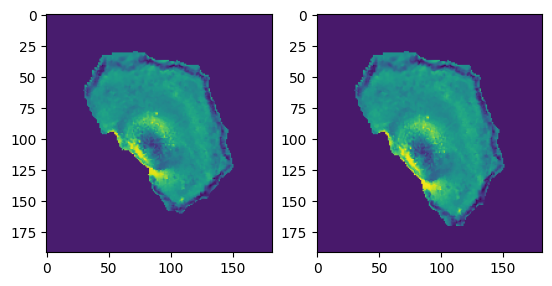

In [125]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(frame_a)
axes[1].imshow(frame_b)

In [8]:
frame_a_norm = ((frame_a - frame_a.min()) / (frame_a.max() - frame_a.min()) * 255).astype(np.int32)
frame_b_norm = ((frame_b - frame_b.min()) / (frame_b.max() - frame_b.min()) * 255).astype(np.int32)


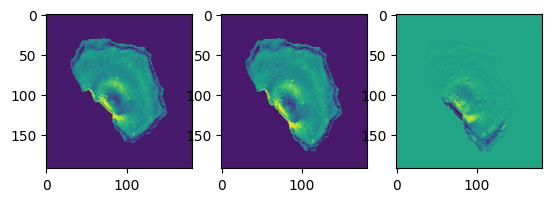

In [127]:
fig, axes = plt.subplots(1, 3)
axes[0].imshow(frame_a_norm)
axes[1].imshow(frame_b_norm)
axes[2].imshow(frame_a_norm - frame_b_norm)

In [118]:
from scipy.interpolate import griddata

def inverse_transform_coordinates(x, y, u, v):
    """Revert physical coordinates back to image coordinates"""
    if y.ndim == 1:
        y = y[::-1]
    else:
        y = y[::-1, :]
    return x, y, u, v

def get_dense_displacement(frame_a, frame_b, window_size=8, overlap=2, 
                           search_area=16, s2n_thresh=1.3, method='cubic'):
    """
    Get pixel-level dense displacement field
    """
    
    x, y, u, v, s2n = piv.simple_piv(
        frame_a, frame_b, 
        window_size=window_size, 
        overlap=overlap,
        search_area_size=search_area, 
        dt=1.0,
        validation_method='sig2noise', 
        plot=False
    )
    
    x, y, u, v = inverse_transform_coordinates(x, y, u, v)
    
    valid = s2n > s2n_thresh
    
    x_valid = x[valid]
    y_valid = y[valid]
    u_valid = u[valid]
    v_valid = v[valid]
    
    h, w = frame_a.shape
    y_dense, x_dense = np.mgrid[0:h:1, 0:w:1]
    
    u_dense = griddata((x_valid, y_valid), u_valid, (x_dense, y_dense), 
                       method=method, fill_value=0)
    v_dense = griddata((x_valid, y_valid), v_valid, (x_dense, y_dense), 
                       method=method, fill_value=0)
    
    u_dense = np.nan_to_num(u_dense, nan=0.0)
    v_dense = np.nan_to_num(v_dense, nan=0.0)
    
    return u_dense, v_dense, (x, y, u, v, valid)

In [119]:
# Get dense field
u_dense, v_dense, sparse_results = get_dense_displacement(
    frame_a_norm, frame_b_norm,
    window_size=10,
    overlap=2,   
    search_area=15, 
    s2n_thresh=1.3,
)

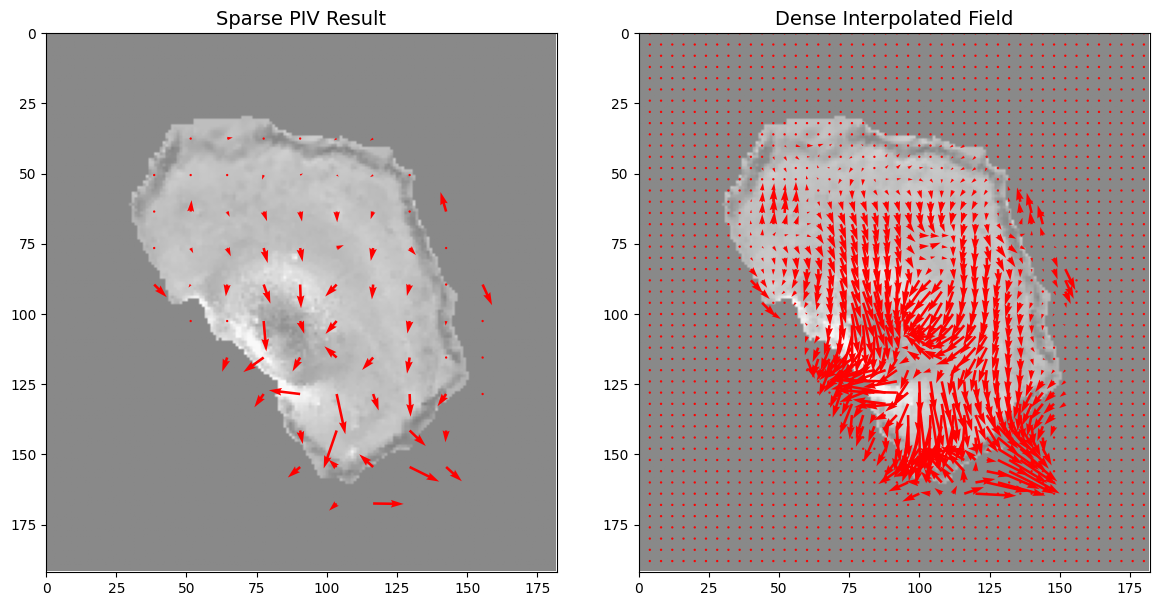

4.186012328020459 2.670792169017334


In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Sparse PIV
x, y, u, v, valid = sparse_results
ax = axes[0]
ax.imshow(frame_a_norm, cmap='gray', alpha=0.5, origin='upper')
ax.quiver(x[valid], y[valid], u[valid], v[valid], scale=70, color='r', width=0.005)
ax.set_title('Sparse PIV Result', fontsize=14)
ax.set_xlim(0, frame_a_norm.shape[1])
ax.set_ylim(frame_a_norm.shape[0], 0)

# Dense interpolated
ax = axes[1]
h, w = u_dense.shape
y_dense, x_dense = np.mgrid[0:h:1, 0:w:1]
ax.imshow(frame_a_norm, cmap='gray', alpha=0.5, origin='upper')
skip = 4 
ax.quiver(x_dense[::skip, ::skip], y_dense[::skip, ::skip], 
          u_dense[::skip, ::skip], v_dense[::skip, ::skip], 
          scale=50, color='r', width=0.005)
ax.set_title('Dense Interpolated Field', fontsize=14)
ax.set_xlim(0, w)
ax.set_ylim(h, 0)

plt.tight_layout()
plt.show()

print(u.max(), v.max())

In [50]:
winsize = 16 # pixels, interrogation window size in frame A
searchsize = 20  # pixels, search in image B
overlap = 8 # pixels, 50% overlap
dt = 0.5

u0, v0, sig2noise = pyprocess.extended_search_area_piv(frame_a_norm.astype(np.int32), 
                                                       frame_b_norm.astype(np.int32), 
                                                       window_size=winsize, 
                                                       overlap=overlap, 
                                                       dt=dt, 
                                                       search_area_size=searchsize, 
                                                       sig2noise_method='peak2peak')

In [ ]:
x, y = pyprocess.get_coordinates(image_size=frame_a.shape, 
                                 search_area_size=searchsize, 
                                 overlap=overlap)

In [78]:
flags = validation.sig2noise_val(sig2noise, threshold=1.0)

u2, v2 = filters.replace_outliers( u0, v0, 
                                   flags,
                                   method='localmean', 
                                   max_iter=3, 
                                   kernel_size=3)

x, y, u3, v3 = scaling.uniform(x, y, u2, v2, 
                               scaling_factor = 1)

x, y, u3, v3 = tools.transform_coordinates(x, y, u3, v3)

tools.save('exp1_001.txt', x, y, u3, v3, flags)


(array([58.,  0.,  0.,  0.,  5., 13.,  5.,  5.,  2.,  2.]),
 array([0.        , 0.21840709, 0.43681419, 0.65522128, 0.87362837,
        1.09203546, 1.31044256, 1.52884965, 1.74725674, 1.96566383,
        2.18407093]),
 <BarContainer object of 10 artists>)

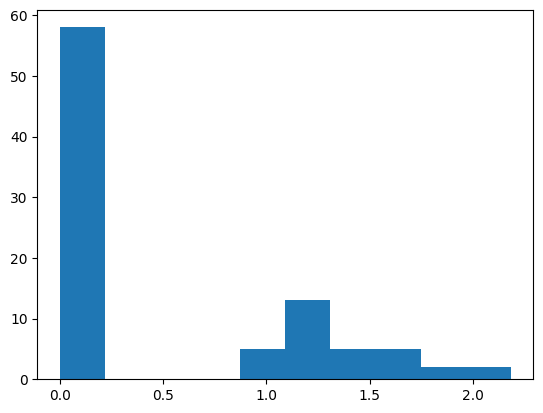

In [74]:
plt.hist(sig2noise.flatten())

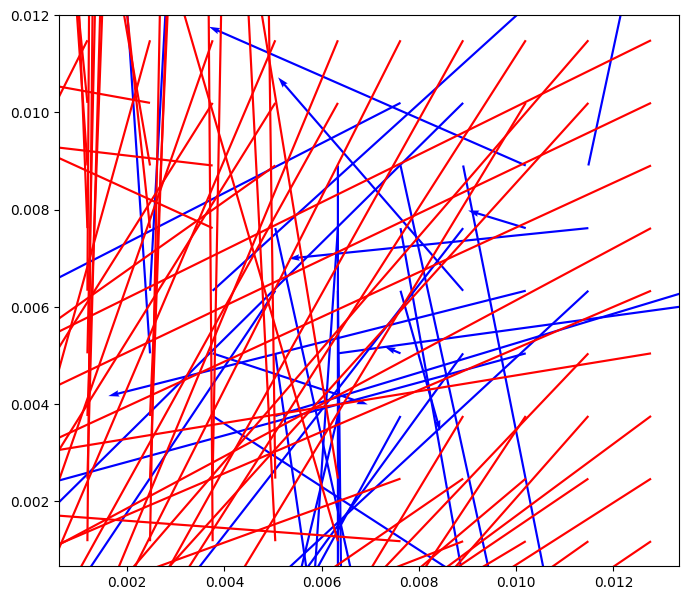

In [79]:

fig, ax = plt.subplots(figsize=(8,8))
tools.display_vector_field('exp1_001.txt', 
                           ax=ax, scaling_factor=1, 
                           scale=0.5, # scale defines here the arrow length
                           width=0.0035, # width is the thickness of the arrow
                           on_img=False,);



In [21]:
flags = validation.sig2noise_val( sig2noise, 
                                 threshold = 1.05 )


u2, v2 = filters.replace_outliers( u0, v0, 
                                   flags,
                                   method='localmean', 
                                   max_iter=3, 
                                   kernel_size=3)

In [31]:
def visualize_flow_quiver(frame, flow_x, flow_y, step=5, scale=1, title="Optical Flow"):
    """
    Visualize optical flow as arrows overlaid on the image.
    
    Parameters
    ----------
    frame : np.ndarray
        Background image
    flow_x : np.ndarray
        Horizontal flow component
    flow_y : np.ndarray
        Vertical flow component
    step : int
        Spacing between arrows (fewer arrows if larger)
    scale : float
        Arrow scale factor
    title : str
        Plot title
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Display background image
    ax.imshow(frame, cmap='gray')
    
    # Create coordinate grid
    h, w = frame.shape
    y, x = np.mgrid[0:h:step, 0:w:step]
    
    # Plot flow as arrows
    ax.quiver(x, y, flow_x[::step, ::step], flow_y[::step, ::step],
              color='red', scale=scale, scale_units='xy', angles='xy')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    
    plt.tight_layout()
    plt.show()

In [12]:
def get_coordinates(
    image_size,
    search_area_size: int,
    overlap: int,
    center_on_field: bool=True
    ):
    """Compute the x, y coordinates of the centers of the interrogation windows.
    for the SQUARE windows only, see also get_rect_coordinates

    the origin (0,0) is like in the image, top left corner
    positive x is an increasing column index from left to right
    positive y is increasing row index, from top to bottom


    Parameters
    ----------
    image_size: two elements tuple
        a two dimensional tuple for the pixel size of the image
        first element is number of rows, second element is
        the number of columns.

    search_area_size: int
        the size of the search area windows, sometimes it's equal to
        the interrogation window size in both frames A and B

    overlap: int = 0 (default is no overlap)
        the number of pixel by which two adjacent interrogation
        windows overlap.


    Returns
    -------
    x : 2d np.ndarray
        a two dimensional array containing the x coordinates of the
        interrogation window centers, in pixels.

    y : 2d np.ndarray
        a two dimensional array containing the y coordinates of the
        interrogation window centers, in pixels.

        Coordinate system 0,0 is at the top left corner, positive
        x to the right, positive y from top downwards, i.e.
        image coordinate system

    """

    # get shape of the resulting flow field as a 2 component array 
    field_shape = (np.array(image_size) - np.array(search_area_size)) // (  # type: ignore
        np.array(search_area_size) - np.array(overlap)
    ) + 1
    

    # compute grid coordinates of the search area window centers
    # note the field_shape[1] (columns) for x
    x = (
        np.arange(field_shape[1]) * (search_area_size - overlap)
        + (search_area_size) / 2.0
    )
    # note the rows in field_shape[0]
    y = (
        np.arange(field_shape[0]) * (search_area_size - overlap)
        + (search_area_size) / 2.0
    )

    # moving coordinates further to the center, so that the points at the
    # extreme left/right or top/bottom
    # have the same distance to the window edges. For simplicity only integer
    # movements are allowed.
    if center_on_field is True:
        x += (
            image_size[1]
            - 1
            - ((field_shape[1] - 1) * (search_area_size - overlap) +
                (search_area_size - 1))
        ) // 2
        y += (
            image_size[0] - 1
            - ((field_shape[0] - 1) * (search_area_size - overlap) +
               (search_area_size - 1))
        ) // 2

        # the origin 0,0 is at top left
        # the units are pixels

    X, Y = np.meshgrid(x,y)

    return (X, Y)

In [ ]:
x, y = get_coordinates(frame_a.shape,
    search_area_size: int,
    overlap: int,
    center_on_field: bool=True)

NameError: name 'x' is not defined

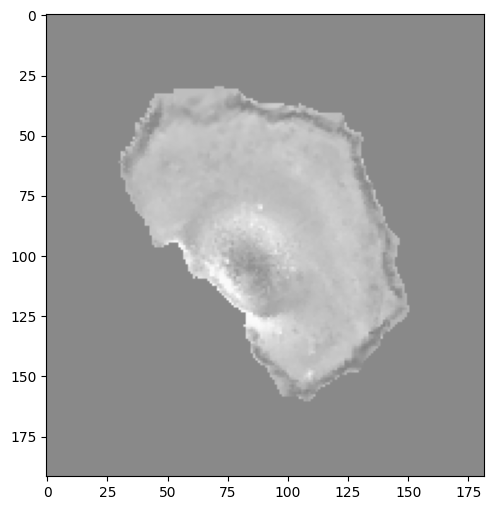

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(frame_a, cmap=plt.get_cmap("gray"), alpha=0.5, origin="upper")
ax.quiver(x, y, u, -v, scale=70,
            color='r', width=.005)
plt.title('Velocity field')
plt.show()

In [3]:
from pathlib import Path
import tifffile
import numpy as np 

# Dossiers source et destination
source_root = Path("/Users/josephinelahmani/Desktop/ofmeca_elas/data")
destination_root = Path("/Users/josephinelahmani/Desktop/ofmeca_elas/data_tiff")

# Parcourt tous les fichiers .npy dans data/, y compris les sous-dossiers
for npy_file in source_root.rglob("*_img.npy"):
    # Chemin relatif à partir de data/
    # Ex. experiment_1/T_50.0_E_1000.0_nu_0.3/im_00_cell_000_img.npy
    relative_path = npy_file.relative_to(source_root)

    # Chemin de sortie avec la même structure de dossiers
    # et extension .tiff au lieu de .npy
    tiff_file = destination_root / relative_path.with_suffix(".tiff")

    # Crée les dossiers de destination si nécessaire
    tiff_file.parent.mkdir(parents=True, exist_ok=True)

    # Charge le tableau NumPy
    image = np.load(npy_file)

    # Écrit l'image TIFF
    tifffile.imwrite(tiff_file, image)

    print(f"Converti :\n  {npy_file}\n  -> {tiff_file}\n")

print("Conversion terminée.")

Converti :
  /Users/josephinelahmani/Desktop/ofmeca_elas/data/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0p35_img.npy
  -> /Users/josephinelahmani/Desktop/ofmeca_elas/data_tiff/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0p35_img.tiff

Converti :
  /Users/josephinelahmani/Desktop/ofmeca_elas/data/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0p25_img.npy
  -> /Users/josephinelahmani/Desktop/ofmeca_elas/data_tiff/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0p25_img.tiff

Converti :
  /Users/josephinelahmani/Desktop/ofmeca_elas/data/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0p45_img.npy
  -> /Users/josephinelahmani/Desktop/ofmeca_elas/data_tiff/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0p45_img.tiff

Converti :
  /Users/josephinelahmani/Desktop/ofmeca_elas/data/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0_img.npy
  -> /Users/josephinelahmani/Desk

In [1]:
from scipy.io import loadmat
test = loadmat('/Users/josephinelahmani/Desktop/ofmeca_elas/PIVlab/results/exp_1/T_50_E_1000_nu_0p3.mat')

In [8]:
from pathlib import Path
exp_folder = Path('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_100.0_E_1000.0_nu_0.3')
matlab_folder = Path('/Users/josephinelahmani/Desktop/ofmeca_elas/PIVlab/results/experiment_1/T_100.0_E_1000.0_nu_0.3')

img_files = sorted(exp_folder.rglob("*_img.npy"))
matlab_files = sorted(exp_folder.glob("*.mat"))

# for i in range(len(img_files)):
#     img = np.load(img_files[i])
#     matlab_

In [6]:
print(matlab_files)
print(img_files)

[PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_00_cell_000.mat'), PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_00_cell_001.mat'), PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_00_cell_002.mat'), PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_00_cell_003.mat'), PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_00_cell_004.mat'), PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_00_cell_005.mat'), PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_01_cell_000.mat'), PosixPath('/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_50.0_E_1000.0_nu_0.3/im_01_cell_001.mat'), PosixPath('/Use

In [9]:
import numpy as np
from scipy.io import loadmat

image = np.load(img_files[0])
matlab_file = loadmat(matlab_files[0])

u = np.nan_to_num(matlab_file['u_original'], nan=0.0)
v = np.nan_to_num(matlab_file['v_original'], nan=0.0)


In [ ]:
v.max()

np.float64(5.177778471507195)

In [76]:
image.shape

(2, 118, 131)

In [75]:
u.shape

(117, 130)

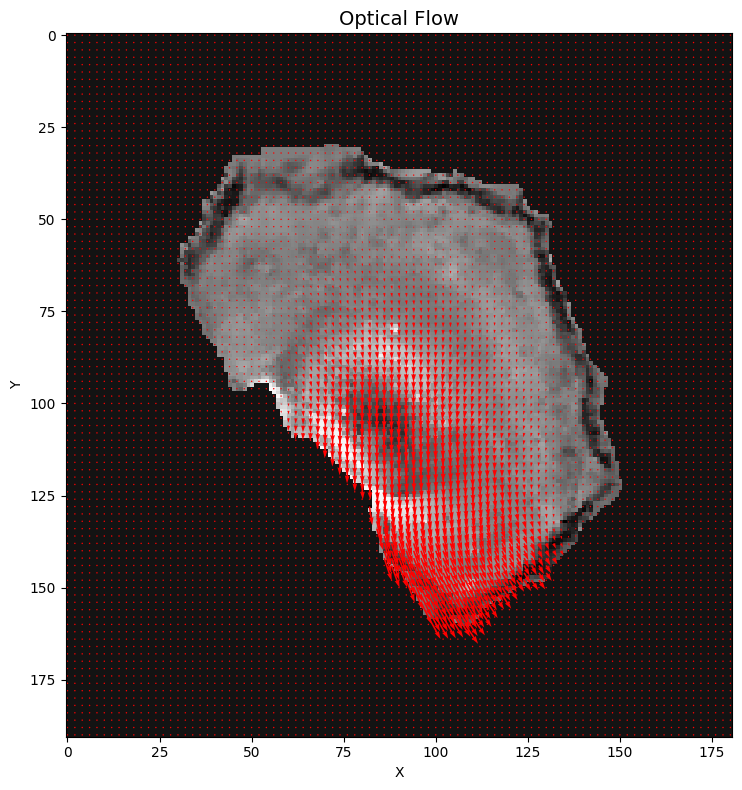

In [67]:
def visualize_flow_quiver(frame, flow_x, flow_y, step=5, scale=1,
                          title="Optical Flow"):
    # Ensure flow components agree
    if flow_x.shape != flow_y.shape:
        raise ValueError(
            f"flow_x and flow_y must have the same shape, got "
            f"{flow_x.shape} and {flow_y.shape}"
        )

    h_flow, w_flow = flow_x.shape

    # Crop background if it is one pixel larger in each direction
    frame = frame[:h_flow, :w_flow]
    mask = frame != 0

    flow_x = flow_x * mask
    flow_y = flow_y * mask
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(frame, cmap="gray", origin="upper")

    # Grid must use FLOW dimensions, not original frame dimensions
    y, x = np.mgrid[0:h_flow:step, 0:w_flow:step]

    u_sub = flow_x[::step, ::step]
    v_sub = flow_y[::step, ::step]

    ax.quiver(
        x, y,
        u_sub, v_sub,
        color="red",
        scale=scale,
        scale_units="xy",
        angles="xy"
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.tight_layout()
    plt.show()
    
visualize_flow_quiver(image[0], u, v, step=2, scale=1)